<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/%EA%B5%B0%EC%A7%91%ED%99%94_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

평균 이동 군집화(Mean Shift Cluster)

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X,y = make_blobs(n_samples=200,n_features=2,centers=3,cluster_std=0.7,random_state=0)

meanshift=MeanShift(bandwidth=0.8)
cluster_labels=meanshift.fit_predict(X)
print(f'cluster labels 유형:{np.unique(cluster_labels)}')


cluster labels 유형:[0 1 2 3 4 5]


군집이 지나치게 세분화돼 군집화됐습니다. 일반적으로 bandwidth값을 작게할수록 군집 개수가 많아집니다.

bandwidth를 살짝 높인 1.0으로 해서 MeanShift를 수행해 보겠습니다.

In [ ]:
meanshift=MeanShift(bandwidth=1)
cluster_labels =meanshift.fit_predict(X)
print(f'class labels 유형:{np.unique(cluster_labels)}')

class labels 유형:[0 1 2]


데이터의 분포 유형에 따라 bandwidth 값의 변화는 군집화 개수에 큰 영향을 미칠 수 있습니다.

In [ ]:
# estimate_bandwidth(): bandwidth 최적화 값 반환
from sklearn.cluster import estimate_bandwidth
bandwidth = estimate_bandwidth(X)
print(f'bandwidth 값:{round(bandwidth,3)}')

bandwidth 값:1.816


In [ ]:
cluster_df = pd.DataFrame(data=X,columns=['ftr1','ftr2'])
cluster_df['target']=y

#estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth=estimate_bandwidth(X)

meanshift=MeanShift(bandwidth=best_bandwidth)
cluster_labels=meanshift.fit_predict(X)
print(f'Cluster labels 유형:{np.unique(cluster_labels)}')

Cluster labels 유형:[0 1 2]


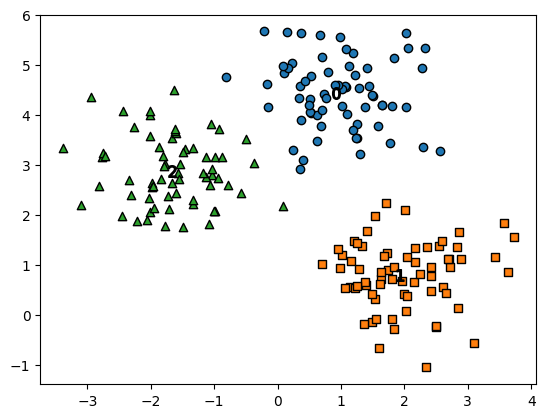

In [ ]:
# 시각화
cluster_df['meanshift_label']=cluster_labels
centers=meanshift.cluster_centers_
unique_labels=np.unique(cluster_labels)
markers=['o','s','^','x','*']

for label in unique_labels:
  label_cluster=cluster_df[cluster_df['meanshift_label']==label]
  center_x_y=centers[label]
  # 군집별로 다른 마커 산점도 적용
  plt.scatter(x=label_cluster['ftr1'],y=label_cluster['ftr2'],edgecolor='k',marker=markers[label])
  #군집별 중심 표현
  plt.scatter(x=center_x_y[0],y=center_x_y[1],s=70,color='k',marker='$%d$' % label)

plt.show()

In [ ]:
# target 값과 군집 label 값 비교
print(cluster_df.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


평균 이동의 장점은 데이터 세트의 형태를 특정 형태로 가정한다든가, 특정 분포도 기반의 모델로 가정하지 않기 때문에 좀 더 유연한 군집화가 가능합니다. 또한 이상치의 영향력도 크지 않으며, 미리 군집의 개수를 정할 필요도 없습니다. 하지만 알고리즘의 수행 시간이 오래 걸리고 무엇보다도 bandwidth의 크기에 따른 군집화 영향도가 매우 큽니다.
이 같은 특징 때문에 일반적으로 평균 이동 군집화 기법은 분석 업무 기반의 데이터 세트보다는 컴퓨터 비전 영역에서 더 많이 사용됩니다. 이미지나 영상 데이터에서 특정 개체를 구분하거나 움직임을 추적하는 데 뛰어난 역할을 수행하는 알고리즘입니다.

### GMM(Gaussian Mixture Models)

GMM 군집화는 데이터를 여러 개의 가우시안 분포가 섞인 것으로 간주합니다. 섞인 데이터 분포에서 개별 유형의 가우시안 분포를 추출합니다.

In [ ]:
# GMM을 이용한 붓꽃 데이터 세트 군집
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

iris=load_iris()
iris_df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
iris_df['target']=iris.target


GaussianMixture 객체의 가장 중요한 초기화 파라미터는 n_componets 입니다. n_components는 gaussian mixture의 모델의 총 개수입니다.

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3,random_state=0).fit(iris.data)
gmm_cluster_labels=gmm.predict(iris.data)

# 군집화 결과를 iris_df의 'gmm_cluster' 칼럼명으로 저장
iris_df['gmm_cluster']=gmm_cluster_labels

# target 값에 따라 gmm_cluster 값이 어떻게 매핑 됐는지 확인
iris_df_result=iris_df.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_df_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [ ]:
kmeans=KMeans(n_clusters=3,init='k-means++',max_iter=300,random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
iris_df['kmeans_cluster']=kmeans_cluster_labels
iris_result=iris_df.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


위의 결과는 어떤 알고리즘이 더 뛰어나다는 의미가 아니라 붓꽃 데이터 세트가 GMM 군집화에 더 효과적이라는 의미입니다.

K-평균은 평균 거리 중심으로 중심을 이동하면서 군집화를 수행하는 방식이므로 개별 군집 내의 데이터가 원형으로 흩어져 있는 경우에 매우 효과적으로 군집화가 수행될 수 있습니다.

### GMM과 k-평균 비교
Kmeans는 원형의 범위에서 군집화를 수행합니다. **데이터 세트가 원형의 범위를 가질수록 KMeans의 군집화 효율은 더욱 높아집니다**. 다음은 make_blobs()의 군집의 수를 3개로 하되, cluster_std를 0.5로 설정해 군집 내의 데이터를 뭉치게 유도한 데이터 세트에 KMeans를 적용한 결과입니다. 이렇게 cluster_std를 작게 설정하면 데이터가 원형 형태로 분산될 수 있습니다.

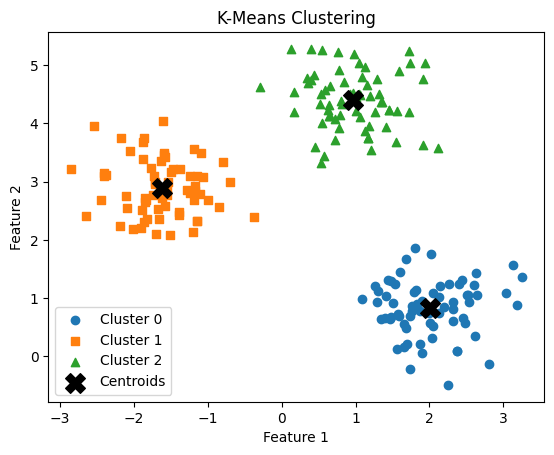

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, MeanShift

# 데이터 생성
X, y = make_blobs(
    n_samples=200,
    n_features=2,
    centers=3,
    cluster_std=0.5,
    random_state=0
)

# 데이터프레임 생성
cluster_df = pd.DataFrame(X, columns=['ftr1', 'ftr2'])

# K-Means 군집화
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    max_iter=300,
    random_state=0
)
kmeans_cluster_labels = kmeans.fit_predict(X)
cluster_df['kmeans_cluster'] = kmeans_cluster_labels


# K-Means 군집화 결과 시각화
unique_labels = np.unique(kmeans_cluster_labels)
markers = ['o', 's', '^']

for label in unique_labels:
    label_cluster = cluster_df[
        cluster_df['kmeans_cluster'] == label
    ]

    # 군집별 산점도
    plt.scatter(
        label_cluster['ftr1'],
        label_cluster['ftr2'],
        marker=markers[label],
        label=f'Cluster {label}'
    )

# 군집 중심 시각화
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    marker='X',
    color='black',
    label='Centroids'
)

plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


### DBSCAN
DBSCAN은 입실론 주변 영역의 최소 데이터 개수를 포함하는 밀도 기준을 충족시키는 데이터인 핵심 포인트를 연결하면서 군집화를 구성하는 방식입니다.


DSCAN을 구성하는 가장 중요한 두 가지 파라미터는 **입실론(epsilon)**으로 표기하는 주변 영역과 이 입실론 주변 영역에 포함되는 최소 데이터의 개수는 **`min points`** 입니다.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN

iris=load_iris()

iris_df = pd.DataFrame(data=iris.data,columns=iris.feature_names)
iris_df['target']=iris.target

dbscan=DBSCAN(eps=0.6,min_samples=8,metric='euclidean')
dbscan_labels=dbscan.fit_predict(iris.data)

iris_df['dbscan_cluster']=dbscan_labels
iris_df['target']=iris.target

iris_result=iris_df.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64


군집 레이블이 -1인 것은 노이즈에 속하는 군집을 의미합니다.

따라서 위 붓꽃 데이터 세트는 DBSCAN에서 0과 1 두 개의 군집으로 군집화됐습니다. Target 값의 유형이 3가지인데, 군집이 2개가 됐다고 군집화 효율이 떨어진다는 의미는 아닙니다.

DBSCAN은 군집 개수를 알고리즘에 따라 자동으로 지정하므로 DBSCAN에서 군집의 개수를 지정하는 것은 무의미하다고 할 수 있습니다.

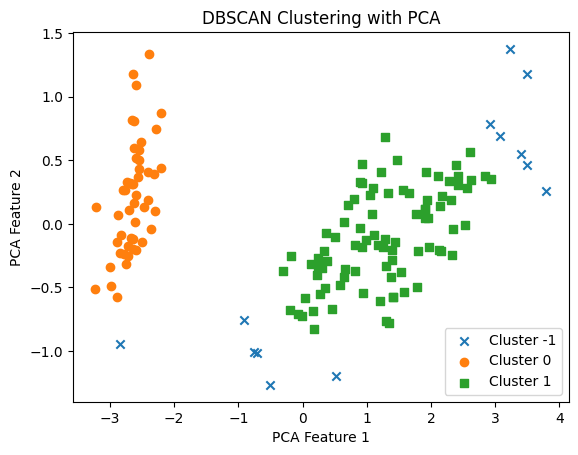

In [ ]:
# DBSCAN으로 군집화 데이터 세트를 2차원 평면에서 표현하기 위해 PCA를 이용해 2개의 피처로 압축 변환한 뒤 시각화
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
pca_transformed=pca.fit_transform(iris.data)
iris_df['ftr1']=pca_transformed[:,0]
iris_df['ftr2']=pca_transformed[:,1]

# DBSCAN 군집화
dbscan = DBSCAN(eps=0.6, min_samples=8)
dbscan_labels = dbscan.fit_predict(iris.data)

# 군집 레이블 저장
iris_df['dbscan_cluster'] = dbscan_labels

# 군집별 시각화
unique_labels = np.unique(dbscan_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = iris_df[
        iris_df['dbscan_cluster'] == label
    ]

    plt.scatter(
        label_cluster['ftr1'],
        label_cluster['ftr2'],
        marker=markers[label % len(markers)] if label != -1 else 'x',
        label=f'Cluster {label}'
    )

plt.title('DBSCAN Clustering with PCA')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.legend()
plt.show()

x(엑스)로 표현된 값은 모두 노이즈입니다. PCA로 2차원으로 표현하면 이상치인 노이즈 데이터가 명확히 드러납니다.


DBSCAN 알고리즘에 적절한 `eps`와 `min_samples` 파라미터를 통해 최적의 군집을 찾는 게 중요합니다. 일반적으로 `eps`의 값을 크게 하면 반경이 커져 포함하는 데이터가 많아지므로 노이즈 데이터 개수가 작아집니다. `min_samples` 를 크게 하면 주어진 반경 내에서 더 많은 데이터를 포함시켜야 하므로 노이즈 데이터 개수가 커지게 됩니다. 데이터 밀도가 더 커져야 하는데, 매우 촘촘한 데이터 분포가 아닌 경우 노이즈로 인식하기 때문입니다.

target  dbscan_cluster
0        0                50
1        1                50
2        1                47
        -1                 3
Name: count, dtype: int64


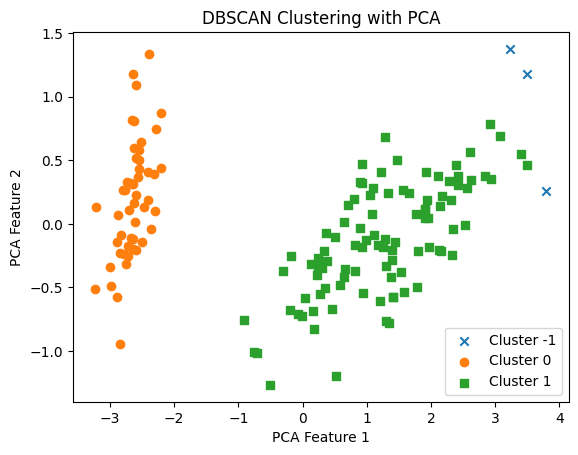

In [ ]:
# eps 0.8로 증가
dbscan = DBSCAN(eps=0.8, min_samples=8,metric='euclidean')
dbscan_labels = dbscan.fit_predict(iris.data)

iris_df['dbscan_cluster']=dbscan_labels

iris_result=iris_df.groupby(['target'])['dbscan_cluster'].value_counts()
print(iris_result)

# 군집별 시각화
unique_labels = np.unique(dbscan_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = iris_df[
        iris_df['dbscan_cluster'] == label
    ]

    plt.scatter(
        label_cluster['ftr1'],
        label_cluster['ftr2'],
        marker=markers[label % len(markers)] if label != -1 else 'x',
        label=f'Cluster {label}'
    )

plt.title('DBSCAN Clustering with PCA')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.legend()
plt.show()

노이즈 군집인 -1이 3개밖에 없습니다.

### DBSCAN 적용하기

`make_circles()`함수를 이용해 내부 원과 외부 원 형태로 돼 있는 2차원 데이터 세트를 만들어보자

`make_circles()` 함수는 오직 2개의 피처만을 생성하므로 별도의 피처 개수를 지정할 필요가 없습니다.



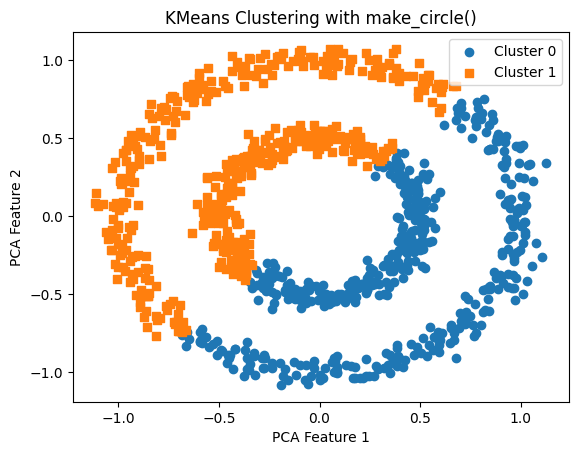

In [ ]:
from sklearn.datasets import make_circles
# KMeans와 GMM 군집화
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# factor : 외부 원과 내부 원의 scale 비율
X,y = make_circles(n_samples=1000,shuffle=True,noise=0.05,random_state=0,factor=0.5)
cluster_df=pd.DataFrame(data=X,columns=['ftr1','ftr2'])
cluster_df['target']=y

kmeans=KMeans(n_clusters=2,max_iter=1000,random_state=0)
kmeans_lables=kmeans.fit_predict(X)
cluster_df['kmeans_cluster']=kmeans_lables

# 군집별 시각화
unique_labels = np.unique(kmeans_lables)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = cluster_df[
        cluster_df['kmeans_cluster'] == label
    ]

    plt.scatter(
        label_cluster['ftr1'],
        label_cluster['ftr2'],
        marker=markers[label % len(markers)] if label != -1 else 'x',
        label=f'Cluster {label}'
    )

plt.title('KMeans Clustering with make_circle()')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.legend()
plt.show()

위, 아래 군집 중심을 기반으로 위와 아래 절반으로 군집화됐습니다.

거리 기반 군집화로는 위와 같이 데이터가 특정한 형태로 지속해서 이어지는 부분을 찾아내기 어렵습니다.

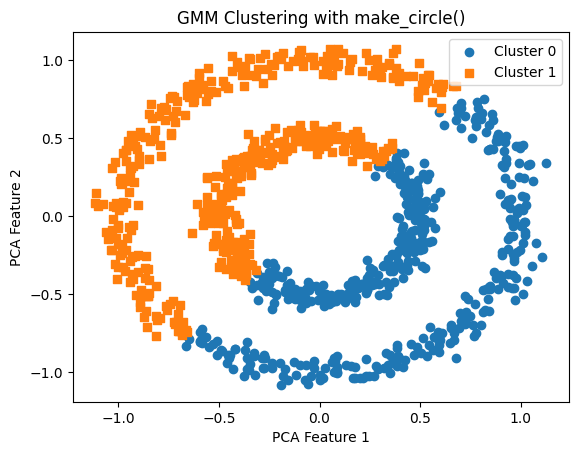

In [ ]:
from sklearn.mixture import GaussianMixture

gmm=GaussianMixture(n_components=2,random_state=0)
gmm_labels=gmm.fit_predict(X)
cluster_df['gmm_cluster']=gmm_labels

# 군집별 시각화
unique_labels = np.unique(gmm_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = cluster_df[
        cluster_df['gmm_cluster'] == label
    ]

    plt.scatter(
        label_cluster['ftr1'],
        label_cluster['ftr2'],
        marker=markers[label % len(markers)] if label != -1 else 'x',
        label=f'Cluster {label}'
    )

plt.title('GMM Clustering with make_circle()')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.legend()
plt.show()

GMM도 앞 절의 일렬로 늘어선 데이터 세트에서는 효과적으로 군집화 적용이 가능했으나, 내부와 외부의 원형으로 구성된 더 복잡한 현태의 데이터 세트에서는 군집화가 원하는 방향으로 되지 않았습니다.


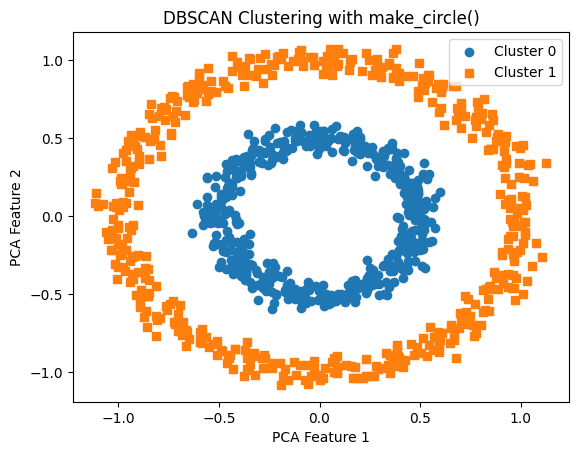

In [ ]:
# DBSCAN으로 make_circles() 데이터 세트 군집화 수행
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2,min_samples=10,metric='euclidean')
dbscan_labels=dbscan.fit_predict(X)
cluster_df['dbscan_cluster']=dbscan_labels

# 군집별 시각화
unique_labels = np.unique(dbscan_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
    label_cluster = cluster_df[
        cluster_df['dbscan_cluster'] == label
    ]

    plt.scatter(
        label_cluster['ftr1'],
        label_cluster['ftr2'],
        marker=markers[label % len(markers)] if label != -1 else 'x',
        label=f'Cluster {label}'
    )

plt.title('DBSCAN Clustering with make_circle()')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.legend()
plt.show()

DBSCAN으로 군집화를 적용해 원하는 방향으로 정확히 군집화가 됐습니다.